# 1. Install + Import Requirements

In [1]:
%pip install mujoco mediapy numpy

import mujoco
import mediapy as media
import numpy as np

%pip install ultralytics

from ultralytics import YOLO

%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.1
[notice] To update, run: C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


# 2. Define MuJoCo XML Scene

In [2]:
xml_string = """
<mujoco>
  <compiler angle="degree"/>
  
  <asset>
    <!-- Define the .obj files as mesh assets -->
    <mesh name="mug_mesh" file="mug.obj"/>
    <mesh name="can_opener_mesh" file="can_opener.obj"/>
    <mesh name="action_fig_mesh" file="action_fig.obj"/>
    <mesh name="shoe_mesh" file="shoe.obj"/>
  </asset>

  <worldbody>
    <light pos="0 0 1.5" dir="0 0 -1" directional="true" diffuse="0.8 0.8 0.8"/>
    <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
    
    <!-- Object: Mug -->
    <body name="mug" pos="0 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="mug_mesh" rgba="0.8 0.2 0.2 1"/>
    </body>
    
    <!-- Object: Can Opener -->
    <body name="can_opener" pos="0.1 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="can_opener_mesh" rgba="0.2 0.8 0.2 1"/>
    </body>
    
    <!-- Object: Action Figure -->
    <body name="action_fig" pos="-0.1 0 0.1">
      <freejoint/>
      <geom type="mesh" mesh="action_fig_mesh" rgba="0.2 0.2 0.8 1"/>
    </body>
    
    <!-- Object: Shoe -->
    <body name="shoe" pos="0 0.1 0.1">
      <freejoint/>
      <geom type="mesh" mesh="shoe_mesh" rgba="0.5 0.5 0.5 1"/>
    </body>
  </worldbody>
</mujoco>
"""
model = mujoco.MjModel.from_xml_string(xml_string)
data = mujoco.MjData(model)

# 3. Generate Training Data for YOLO Finetuning
This will be labelled bounding boxes from openCV of the objects initialized to random transforms

Generating synthetic data. This will take a moment...
Synthetic Dataset Generation Complete!
Visual sanity check:


""

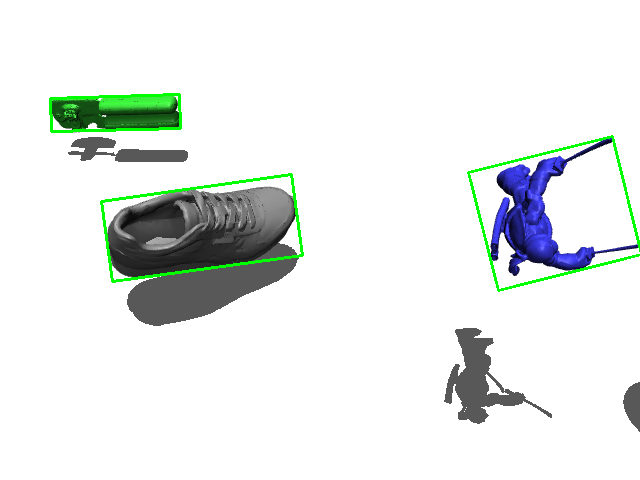

In [3]:


import os
import cv2
import yaml

dataset_dir = "datasets/mujoco_obb"

# set up datasets
os.makedirs(f"{dataset_dir}/images/train", exist_ok=True)
os.makedirs(f"{dataset_dir}/labels/train", exist_ok=True)

# all objects have class 0, because we dont care what they are - just need to sweep them.
classes = {"mug": 0, "can_opener": 0, "action_fig": 0, "shoe": 0}
object_names = list(classes.keys())         # must be after classes dict

# use MuJoCo's built in segmenter
seg_renderer = mujoco.Renderer(model, 480, 640)
seg_renderer.enable_segmentation_rendering()
renderer = mujoco.Renderer(model, 480, 640)  # must be after seg_renderer

# generate 100 training images
print("Generating synthetic data. This will take a moment...")
frames_to_generate = 100
vis_img = None

for i in range(frames_to_generate):
    # random positions and rotations for each frame
    for obj_name in object_names:
        body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        
        rand_x, rand_y = np.random.uniform(-0.4, 0.4, size=2)

        # add random rotation
        rand_angle = np.random.uniform(0, 2 * np.pi)
        q_z = [np.cos(rand_angle/2), 0, 0, np.sin(rand_angle/2)]
        
        qpos_start = model.jnt_qposadr[model.body_jntadr[body_id]]
        data.qpos[qpos_start:qpos_start+3] = [rand_x, rand_y, 0.2]
        data.qpos[qpos_start+3:qpos_start+7] = q_z
        
    mujoco.mj_forward(model, data)
    num_steps = np.random.randint(10, 100)  # let the objects fall a random amount, would like mid-air support
    for _ in range(num_steps):  # roll out physics
        mujoco.mj_step(model, data)
        
    # render scene and segments
    renderer.update_scene(data)
    rgb_img = renderer.render()
    
    seg_renderer.update_scene(data)
    seg_img = seg_renderer.render()
    
    img_h, img_w = rgb_img.shape[:2]
    
    # save the last frame to see if the model is working correctly
    if i == frames_to_generate - 1:
        vis_img = rgb_img.copy()

    # now we can make the label for this data point
    label_file = open(f"{dataset_dir}/labels/train/frame_{i}.txt", "w")
    
    for obj_name, class_idx in classes.items():
        body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        
        # get the MuJoCo geom_id
        geom_id = model.body_geomadr[body_id]
        
        # create binary mask for this object
        mask = np.uint8(seg_img[:, :, 0] == geom_id) * 255
        
        # use openCV to get the bounding box
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        if contours:
            c = max(contours, key=cv2.contourArea)
            # only save the bounding box if not obscured or offscreen
            if cv2.contourArea(c) > 50: 
                # minAreaRect gets the box corners
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                
                if vis_img is not None:
                    # draw a green box in the visualization image for us to see if its working
                    cv2.drawContours(vis_img, [np.int32(box)], 0, (0, 255, 0), 2)
                
                # must normalize coordinates between 0.0 and 1.0 to work in YOLO
                box[:, 0] /= img_w
                box[:, 1] /= img_h
                
                # yolo format: "class_idx x1 y1 x2 y2 x3 y3 x4 y4"
                label_str = " ".join([f"{coord:.5f}" for coordinate in box for coord in coordinate])
                label_file.write(f"{class_idx} {label_str}\n")
                
    label_file.close()
    
    # create image for this data point, opencv uses BGR format
    cv2.imwrite(f"{dataset_dir}/images/train/frame_{i}.jpg", cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

print("Synthetic Dataset Generation Complete!")

# view the final frame with the visualization as a sanity check
if vis_img is not None:
    print("Visual sanity check:")
    media.show_image(vis_img)

# 4. Fine Tune YOLO
Use the data set of labelled images we just generated.

In [5]:
# ultralytics needs dataset.yaml, so make it
yaml_config = {
    'path': os.path.abspath(dataset_dir),
    'train': 'images/train',
    'val': 'images/train', # WILL CHANGE: need to use actual validation set
    # only one class
    'names': {0: "object"}
}

with open('mujoco_dataset.yaml', 'w') as f:
    yaml.dump(yaml_config, f)

# import base YOLO
model_obb = YOLO('yolov8n-obb.pt')

# train
results = model_obb.train(data='mujoco_dataset.yaml', epochs=25, imgsz=640, device="cpu", verbose=False)

print("Training finished!")


Ultralytics 8.4.46  Python-3.14.2 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1245U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mujoco_dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
       2/25         0G          0      72.56          0          0          0        640: 100% ━━━━━━━━━━━━ 7/7 4.9s/it 34.0s3.6sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4s/it 10.1s.8ss
                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels


C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
       3/25         0G          0      55.77          0          0          0        640: 100% ━━━━━━━━━━━━ 7/7 4.6s/it 31.9s3.0sss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5s/it 10.2s.8ss
                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss angle_loss  Instances       Size
      25/25         0G          0      3.292          0          0          0        640: 100% ━━━━━━━━━━━━ 7/7 4.3s/it 30.4s3.1ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3s/it 9.1s1.6ss
                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels


C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



25 epochs completed in 0.293 hours.
Optimizer stripped from C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4\weights\last.pt, 6.5MB
Optimizer stripped from C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4\weights\best.pt, 6.5MB

Validating C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4\weights\best.pt...
Ultralytics 8.4.46  Python-3.14.2 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1245U)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.3s/it 8.8s1.6ss


C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\manandkumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)


                   all        100          0          0          0          0          0
WARNING no labels found in obb set, cannot compute metrics without labels
Speed: 1.3ms preprocess, 80.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to C:\Users\manandkumar\OneDrive - Stony Brook University\Desktop\ESE564\Proj\runs\obb\train-4
Training finished!


# 4. Test Perception Module

In [4]:
class PerceptionModule:
    """
    Combines YOLO 2D Object Detection with Depth maps to estimate 
    the 3D transform (position and orientation) of detected objects 
    relative to the camera.
    """
    def __init__(self, weights_path, fovy_degrees=45.0):
        self.model = YOLO(weights_path)
        # default camera has 45 degree vertical field of view
        self.fovy_degrees = fovy_degrees
        
    def get_transforms(self, rgb_image, depth_image):
        # run model
        results = self.model(rgb_image, verbose=False)[0]
        
        objects = []
        if results.obb is not None:
            h, w = rgb_image.shape[:2]
            
            # get camera intrinsics
            fovy_rad = np.deg2rad(self.fovy_degrees)
            fy = (h / 2.0) / np.tan(fovy_rad / 2.0)
            fx = fy
            cx = w / 2.0
            cy = h / 2.0
            
            for box in results.obb:
                # get OBB parameters
                x_center, y_center, width, height, rotation = box.xywhr[0].cpu().numpy()
                class_id = int(box.cls[0].item())
                confidence = float(box.conf[0].item())
                
                # get depth at each object's center
                u = int(np.clip(x_center, 0, w - 1))
                v = int(np.clip(y_center, 0, h - 1))
                z = depth_image[v, u]
                
                # use deprojection formula:
                x = (u - cx) * z / fx
                y = (v - cy) * z / fy
                
                transform = {
                    "class": results.names[class_id],
                    "position_camera_frame": np.array([x, y, z]),
                    "rotation_rad": rotation,
                    "confidence": confidence,
                    "pixel_u": u,
                    "pixel_v": v
                }
                objects.append(transform)
                
        # return the list of object transforms and the annotated image
        return objects, results.plot()

In [5]:
import time
import cv2

# make perception module
perceptor = PerceptionModule("runs/obb/train-3/weights/best.pt")

# set up depth renderer
depth_renderer = mujoco.Renderer(model, 480, 640)
depth_renderer.enable_depth_rendering()

# randomize object transforms
for obj_name in object_names:
    body_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
    data.qpos[model.jnt_qposadr[model.body_jntadr[body_id]]:model.jnt_qposadr[model.body_jntadr[body_id]]+3] = [
        np.random.uniform(-0.4, 0.4), np.random.uniform(-0.4, 0.4), 0.2
    ]
mujoco.mj_forward(model, data)

# make OpenCV window for real-time display
cv2.namedWindow('Perception Module', cv2.WINDOW_NORMAL)

# total steps to run
num_steps = 2000

# for performance, set the interval 5 or above
inference_step_interval = 5

try:
    for step in range(num_steps): 
        mujoco.mj_step(model, data)
        
        # only render and run the model every inference step interval
        if step % inference_step_interval == 0:
            # Update both renderers with current physics state
            renderer.update_scene(data)
            depth_renderer.update_scene(data)
            
            # Fetch RGB and Depth images
            img_rgb = renderer.render()
            img_depth = depth_renderer.render()

            # Use our perception module to calculate 3D transforms
            detected_objects, annotated_rgb = perceptor.get_transforms(img_rgb, img_depth)
            
            # OpenCV needs bgr
            annotated_bgr = cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR)

            # Render text overlay with 3D coordinates on the image
            y_offset = 30
            for obj in detected_objects:
                pos = obj['position_camera_frame']
                text = f"{obj['class']}: [X: {pos[0]:.2f}, Y: {pos[1]:.2f}, Z: {pos[2]:.2f}]"
                cv2.putText(annotated_bgr, text, (10, y_offset), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                y_offset += 25
            
            # display in OpenCV window
            cv2.imshow('Perception Module', annotated_bgr)
            
            # press 'q' to quit
            if cv2.waitKey(1) & 0xFF == ord('q'):
                break
                
        time.sleep(0.002)
        
finally:
    # this forces the window to close
    cv2.destroyAllWindows()
    for i in range(10):
        cv2.waitKey(1)

# 5. Scene with Robot (Broom + Franka Panda)
Build the combined MuJoCo scene using `mujoco.MjSpec`.

The broom mesh is generated **programmatically** — correct dimensions,
zero licensing issues, no external conversion needed.

In [6]:
import subprocess, os

# ── 0. Generate broom.obj if not already present ──────────────────────────
def _make_broom_obj(path, n_seg=20):
    import numpy as np
    verts, faces = [], []
    r, hz0, hz1 = 0.015, 0.05, 0.75
    for i in range(n_seg):
        a = 2*np.pi*i/n_seg; verts.append((r*np.cos(a), r*np.sin(a), hz0))
    for i in range(n_seg):
        a = 2*np.pi*i/n_seg; verts.append((r*np.cos(a), r*np.sin(a), hz1))
    verts += [(0,0,hz0),(0,0,hz1)]
    bc, tc = 2*n_seg+1, 2*n_seg+2
    for i in range(n_seg):
        v0,v1,v2,v3 = i+1, i%n_seg+2, n_seg+i%n_seg+2, n_seg+i+1
        faces += [(v0,v1,v2),(v0,v2,v3)]
    for i in range(n_seg): faces.append((bc, i%n_seg+2, i+1))
    for i in range(n_seg): faces.append((tc, n_seg+i+1, n_seg+i%n_seg+2))
    bx,by,bz0,bz1 = 0.12,0.03,0.0,0.05; o = len(verts)+1
    for bv in [(-bx,-by,bz0),(bx,-by,bz0),(bx,by,bz0),(-bx,by,bz0),
               (-bx,-by,bz1),(bx,-by,bz1),(bx,by,bz1),(-bx,by,bz1)]:
        verts.append(bv)
    faces += [(o,o+2,o+1),(o,o+3,o+2),(o+4,o+5,o+6),(o+4,o+6,o+7),
              (o,o+1,o+5),(o,o+5,o+4),(o+1,o+2,o+6),(o+1,o+6,o+5),
              (o+2,o+3,o+7),(o+2,o+7,o+6),(o+3,o,o+4),(o+3,o+4,o+7)]
    with open(path,"w") as f:
        f.write("# Parametric broom: handle r=0.015m z=[0.05,0.75]; head 0.24x0.06x0.05m\n")
        for v in verts: f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for fc in faces: f.write(f"f {fc[0]} {fc[1]} {fc[2]}\n")
    print(f"Generated {path}  ({len(verts)} verts, {len(faces)} faces)")

if not os.path.exists("broom.obj"):
    _make_broom_obj("broom.obj")
else:
    print("broom.obj already present")

# ── 1. Download Franka Panda model (mujoco_menagerie) ─────────────────────
if not os.path.exists("mujoco_menagerie"):
    subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/google-deepmind/mujoco_menagerie.git"],
        check=True,
    )

PANDA_XML = "mujoco_menagerie/franka_emika_panda/panda.xml"

# ── 2. Base scene XML (broom mesh included directly) ─────────────────────
# Broom geometry (single geom = visual + collision):
#   Handle : cylinder r=0.015 m,  z = [0.05, 0.75]
#   Head   : box ±0.12 x ±0.03 x [0, 0.05] m
# Grasp point for IK: broom_world_pos + [0, 0, 0.55]  (upper handle)
BASE_XML = """
<mujoco model="sweep_scene">
  <compiler angle="radian"/>
  <option gravity="0 0 -9.81"/>
  <asset>
    <mesh name="mug_mesh"        file="mug.obj"/>
    <mesh name="can_opener_mesh" file="can_opener.obj"/>
    <mesh name="action_fig_mesh" file="action_fig.obj"/>
    <mesh name="shoe_mesh"       file="shoe.obj"/>
    <mesh name="broom_mesh"      file="broom.obj"/>
  </asset>
  <worldbody>
    <light pos="0 0 2" dir="0 0 -1" directional="true" diffuse="0.8 0.8 0.8"/>
    <geom type="plane" size="1 1 0.1" rgba="0.9 0.9 0.9 1"/>
    <!-- Fixed overhead camera used by PerceptionModule -->
    <camera name="overhead_cam" pos="0 0 1.5" euler="0 0 0" fovy="45"/>
    <!-- Broom: freejoint so it can be grasped and lifted -->
    <body name="broom" pos="0.3 0.0 0.0">
      <freejoint name="broom_joint"/>
      <geom name="broom_geom" type="mesh" mesh="broom_mesh"
            rgba="0.65 0.38 0.12 1" contype="1" conaffinity="1"/>
    </body>
    <!-- Sweepable objects -->
    <body name="mug"        pos="0    0    0.1"><freejoint/><geom type="mesh" mesh="mug_mesh"        rgba="0.8 0.2 0.2 1"/></body>
    <body name="can_opener" pos="0.1  0    0.1"><freejoint/><geom type="mesh" mesh="can_opener_mesh" rgba="0.2 0.8 0.2 1"/></body>
    <body name="action_fig" pos="-0.1 0    0.1"><freejoint/><geom type="mesh" mesh="action_fig_mesh" rgba="0.2 0.2 0.8 1"/></body>
    <body name="shoe"       pos="0    0.1  0.1"><freejoint/><geom type="mesh" mesh="shoe_mesh"       rgba="0.5 0.5 0.5 1"/></body>
  </worldbody>
</mujoco>
"""

# ── 3. Compose with MjSpec (Panda only — broom is already in BASE_XML) ────
scene_spec = mujoco.MjSpec.from_string(BASE_XML)
panda_spec = mujoco.MjSpec.from_file(PANDA_XML)

# Add EE site to panda hand (menagerie panda.xml has no sites)
panda_hand = next(b for b in panda_spec.bodies if b.name == "hand")
ee_site      = panda_hand.add_site()
ee_site.name = "attachment_site"
ee_site.pos  = [0.0, 0.0, 0.1]   # ~10 cm toward fingertips in hand local frame

panda_frame       = scene_spec.worldbody.add_frame()
panda_frame.pos   = [0.7, 0.0, 0.0]
panda_frame.quat  = [0.0, 0.0, 0.0, 1.0] # face the table (π around z)
scene_spec.attach(panda_spec, prefix="panda_", frame=panda_frame)

# ── 4. Compile ─────────────────────────────────────────────────────────────
robot_model = scene_spec.compile()
robot_data  = mujoco.MjData(robot_model)
mujoco.mj_forward(robot_model, robot_data)

# ── 5. Resolve names ──────────────────────────────────────────────────────
site_names = [mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_SITE, i)
              for i in range(robot_model.nsite)]
print("Sites in scene:", site_names)

PANDA_JOINTS  = [f"panda_joint{i}" for i in range(1, 8)]
FINGER_JOINTS = ["panda_finger_joint1", "panda_finger_joint2"]
# Confirm EE_SITE matches one of the printed site names above
EE_SITE = "panda_attachment_site"

print(f"robot_model compiled — nq: {robot_model.nq}, nv: {robot_model.nv}")


broom.obj already present
Sites in scene: ['panda_attachment_site']
robot_model compiled — nq: 44, nv: 39


# 6. Retrain YOLO with Broom Class
Add the broom (class 1) to synthetic training data and retrain YOLOv8-OBB.

Generating synthetic data with broom. This will take a moment...
Dataset generation complete!


""

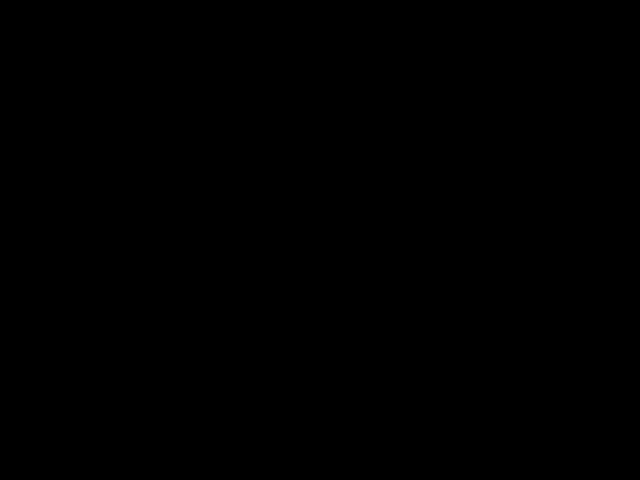

Ultralytics 8.4.46  Python-3.14.2 torch-2.11.0+cpu CPU (12th Gen Intel Core i5-1245U)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=mujoco_dataset_with_broom.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

KeyboardInterrupt: 

In [26]:
import os, cv2, yaml

DATASET_DIR_R = "datasets/mujoco_obb_with_broom"
os.makedirs(f"{DATASET_DIR_R}/images/train", exist_ok=True)
os.makedirs(f"{DATASET_DIR_R}/labels/train", exist_ok=True)

# Sweepable objects → class 0, broom → class 1
classes_r = {
    "mug": 0, "can_opener": 0, "action_fig": 0, "shoe": 0,
    "broom": 1,
}

seg_renderer_r = mujoco.Renderer(robot_model, 480, 640)
seg_renderer_r.enable_segmentation_rendering()
renderer_r = mujoco.Renderer(robot_model, 480, 640)

object_names_r = list(classes_r.keys())

print("Generating synthetic data with broom. This will take a moment...")
frames_to_generate = 100
vis_img_r = None

for i in range(frames_to_generate):
    for obj_name in object_names_r:
        body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        rand_x, rand_y = np.random.uniform(-0.35, 0.35, size=2)
        rand_angle = np.random.uniform(0, 2 * np.pi)
        q_z = [np.cos(rand_angle / 2), 0, 0, np.sin(rand_angle / 2)]
        qpos_start = robot_model.jnt_qposadr[robot_model.body_jntadr[body_id]]
        robot_data.qpos[qpos_start:qpos_start + 3] = [rand_x, rand_y, 0.15]
        robot_data.qpos[qpos_start + 3:qpos_start + 7] = q_z

    mujoco.mj_forward(robot_model, robot_data)
    for _ in range(np.random.randint(10, 60)):
        mujoco.mj_step(robot_model, robot_data)

    renderer_r.update_scene(robot_data, camera="overhead_cam")
    rgb_img = renderer_r.render()

    seg_renderer_r.update_scene(robot_data, camera="overhead_cam")
    seg_img = seg_renderer_r.render()

    img_h, img_w = rgb_img.shape[:2]
    if i == frames_to_generate - 1:
        vis_img_r = rgb_img.copy()

    label_file = open(f"{DATASET_DIR_R}/labels/train/frame_{i}.txt", "w")

    for obj_name, class_idx in classes_r.items():
        body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, obj_name)
        geom_id = robot_model.body_geomadr[body_id]
        mask = np.uint8(seg_img[:, :, 0] == geom_id) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            c = max(contours, key=cv2.contourArea)
            if cv2.contourArea(c) > 50:
                rect = cv2.minAreaRect(c)
                box = cv2.boxPoints(rect)
                if vis_img_r is not None:
                    cv2.drawContours(vis_img_r, [np.int32(box)], 0, (0, 255, 0), 2)
                box[:, 0] /= img_w
                box[:, 1] /= img_h
                label_str = " ".join([f"{coord:.5f}" for coordinate in box for coord in coordinate])
                label_file.write(f"{class_idx} {label_str}\n")

    label_file.close()
    cv2.imwrite(f"{DATASET_DIR_R}/images/train/frame_{i}.jpg",
                cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))

print("Dataset generation complete!")
if vis_img_r is not None:
    media.show_image(vis_img_r)

# Write YAML and retrain
yaml_config_r = {
    "path": os.path.abspath(DATASET_DIR_R),
    "train": "images/train",
    "val":   "images/train",
    "names": {0: "object", 1: "broom"},
}
with open("mujoco_dataset_with_broom.yaml", "w") as f:
    yaml.dump(yaml_config_r, f)

model_obb_r = YOLO("yolov8n-obb.pt")
results_r = model_obb_r.train(
    data="mujoco_dataset_with_broom.yaml",
    epochs=25, imgsz=640, device="cpu", verbose=False,
)
print("Training finished!")

# Automatically resolve the correct weights path from the completed training run
BROOM_WEIGHTS = str(results_r.save_dir / "weights" / "best.pt")
print(f"BROOM_WEIGHTS: {BROOM_WEIGHTS}")

# 6. Grasp Planning

In [ ]:
import numpy as np
import mujoco
import cv2
import time

PANDA_READY = np.array([0, -np.pi / 4, 0, -3 * np.pi / 4, 0, np.pi / 2, np.pi / 4], dtype=np.float32)

# --- Joint limits for IK projection ---
def _get_joint_limits(model, joint_names):
    limits = []
    for name in joint_names:
        j_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        lo, hi = model.jnt_range[j_id]
        if lo == 0.0 and hi == 0.0:
            lo, hi = -3.0, 3.0
        limits.append((float(lo), float(hi)))
    return np.array(limits, dtype=np.float32)

JOINT_LIMITS = _get_joint_limits(robot_model, PANDA_JOINTS)

def _clip_q(q, limits):
    return np.minimum(np.maximum(q, limits[:, 0]), limits[:, 1])

# --- Reset scene to model defaults ---
def reset_scene(model, data, arm_qpos=None):
    mujoco.mj_resetData(model, data)
    data.qpos[:] = model.qpos0
    data.qvel[:] = 0.0
    if model.nu > 0:
        data.ctrl[:] = 0.0
    if arm_qpos is not None:
        jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in PANDA_JOINTS]
        qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
        for i, adr in enumerate(qpos_adr):
            data.qpos[adr] = arm_qpos[i]
    mujoco.mj_forward(model, data)

# --- Simple settle step to let objects fall ---
def settle_scene(model, data, arm_qpos=None, steps=200):
    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in PANDA_JOINTS]
    qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
    dof_adr = [model.jnt_dofadr[j] for j in jnt_ids]
    for _ in range(steps):
        if arm_qpos is not None:
            for i, adr in enumerate(qpos_adr):
                data.qpos[adr] = arm_qpos[i]
            for d in dof_adr:
                data.qvel[d] = 0.0
        mujoco.mj_step(model, data)
    mujoco.mj_forward(model, data)

# --- Position + orientation IK (damped least squares) ---
def solve_ik_to_site(
    model,
    data,
    site_name,
    target_pos,
    q_init,
    target_rot=None,
    max_iters=400,
    tol=2e-3,
    rot_tol=5e-2,
    damp=5e-3,
    rot_w=0.2,
 ):
    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in PANDA_JOINTS]
    qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
    dof_adr = [model.jnt_dofadr[j] for j in jnt_ids]
    site_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SITE, site_name)

    target_pos = target_pos.copy()
    target_pos[2] = max(target_pos[2], 0.05)

    q = q_init.copy()
    for _ in range(max_iters):
        q = _clip_q(q, JOINT_LIMITS)
        for i, adr in enumerate(qpos_adr):
            data.qpos[adr] = q[i]
        mujoco.mj_forward(model, data)

        cur = data.site_xpos[site_id].copy()
        err_pos = target_pos - cur
        if np.linalg.norm(err_pos) > 0.1:
            err_pos = err_pos / np.linalg.norm(err_pos) * 0.1

        jacp = np.zeros((3, model.nv))
        jacr = np.zeros((3, model.nv))
        mujoco.mj_jacSite(model, data, jacp, jacr, site_id)

        rot_err = None
        if target_rot is not None:
            cur_mat = data.site_xmat[site_id].reshape(3, 3)
            quat_cur = np.zeros(4, dtype=np.float64)
            quat_tgt = np.zeros(4, dtype=np.float64)
            mujoco.mju_mat2Quat(quat_cur, cur_mat.flatten())
            mujoco.mju_mat2Quat(quat_tgt, target_rot.flatten())
            quat_err = np.zeros(4, dtype=np.float64)
            quat_cur_conj = quat_cur.copy()
            quat_cur_conj[1:] *= -1.0
            mujoco.mju_mulQuat(quat_err, quat_tgt, quat_cur_conj)
            rot_err = np.zeros(3, dtype=np.float64)
            mujoco.mju_quat2Vel(rot_err, quat_err, 1.0)
            if np.linalg.norm(rot_err) > 0.5:
                rot_err = rot_err / np.linalg.norm(rot_err) * 0.5

        if np.linalg.norm(err_pos) < tol and (rot_err is None or np.linalg.norm(rot_err) < rot_tol):
            return q, True

        if rot_err is not None:
            err = np.concatenate([err_pos, rot_w * rot_err])
            J = np.vstack([jacp[:, dof_adr], rot_w * jacr[:, dof_adr]])
            A = J @ J.T + damp * np.eye(6)
        else:
            err = err_pos
            J = jacp[:, dof_adr]
            A = J @ J.T + damp * np.eye(3)

        dq = J.T @ np.linalg.solve(A, err)
        q = q + 0.5 * dq

    return q, False

def _get_arm_actuator_ids(model, joint_names):
    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in joint_names]
    jnt_to_idx = {jid: i for i, jid in enumerate(jnt_ids)}
    act_ids = []
    for act_id in range(model.nu):
        joint_id = int(model.actuator_trnid[act_id, 0])
        if joint_id in jnt_to_idx:
            act_ids.append((jnt_to_idx[joint_id], act_id))
    act_ids.sort(key=lambda x: x[0])
    return [act_id for _, act_id in act_ids], jnt_ids

def _find_gripper_actuators_by_name(model):
    act_ids = []
    for act_id in range(model.nu):
        act_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id)
        if act_name and ("finger" in act_name or "gripper" in act_name):
            act_ids.append(act_id)
    return act_ids

def _find_gripper_actuators_by_tendon(model):
    act_ids = []
    for act_id in range(model.nu):
        if int(model.actuator_trntype[act_id]) != int(mujoco.mjtTrn.mjTRN_TENDON):
            continue
        tendon_id = int(model.actuator_trnid[act_id, 0])
        tendon_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_TENDON, tendon_id)
        if tendon_name and ("finger" in tendon_name or "gripper" in tendon_name or "split" in tendon_name):
            act_ids.append(act_id)
    return act_ids

def _get_gripper_actuator_ids(model, joint_names):
    hardcoded = ["panda_actuator8"]
    hardcoded_ids = [
        mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, name)
        for name in hardcoded
    ]
    if all(aid >= 0 for aid in hardcoded_ids):
        return hardcoded_ids

    tendon_act_ids = _find_gripper_actuators_by_tendon(model)
    if tendon_act_ids:
        return tendon_act_ids

    jnt_ids = [mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, n) for n in joint_names]
    jnt_to_idx = {jid: i for i, jid in enumerate(jnt_ids)}
    act_ids = []
    for act_id in range(model.nu):
        joint_id = int(model.actuator_trnid[act_id, 0])
        if joint_id in jnt_to_idx:
            act_ids.append((jnt_to_idx[joint_id], act_id))
    act_ids.sort(key=lambda x: x[0])
    joint_act_ids = [act_id for _, act_id in act_ids]
    if joint_act_ids:
        return joint_act_ids

    name_act_ids = _find_gripper_actuators_by_name(model)
    if name_act_ids:
        return name_act_ids

    # Fall back to last two actuators (Panda gripper in menagerie).
    if model.nu >= 2:
        return [model.nu - 2, model.nu - 1]
    return []

def _set_gripper_qpos(model, data, joint_names, value):
    for name in joint_names:
        j_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, name)
        if j_id < 0:
            continue
        adr = model.jnt_qposadr[j_id]
        data.qpos[adr] = float(value)
    mujoco.mj_forward(model, data)

def _debug_actuators(model, act_ids):
    info = []
    for act_id in act_ids:
        act_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id)
        joint_id = int(model.actuator_trnid[act_id, 0])
        joint_name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, joint_id)
        gear = float(model.actuator_gear[act_id, 0])
        lo, hi = model.actuator_forcerange[act_id]
        info.append((act_id, act_name, joint_name, gear, (float(lo), float(hi))))
    print("Actuators driving arm:", info)
    print("Total actuators:", model.nu)

def _set_torque_limits(model, act_ids, arm_limits, wrist_limits):
    for i, act_id in enumerate(act_ids):
        limit = arm_limits if i < 4 else wrist_limits
        model.actuator_forcerange[act_id, 0] = -float(limit)
        model.actuator_forcerange[act_id, 1] = float(limit)
    print("Updated actuator forcerange:", [tuple(model.actuator_forcerange[a]) for a in act_ids])

def _apply_direct_torque(data, dof_adr, tau):
    data.qfrc_applied[:] = 0.0
    for i, d in enumerate(dof_adr):
        data.qfrc_applied[d] = float(tau[i])

# --- Execute joint path with PD torque control ---
def execute_joint_path(
    model,
    data,
    path,
    renderer,
    camera="overhead_cam",
    hold_steps=8,
    sleep_s=0.0,
    kp=800.0,
    kd=30.0,
    wait_on_exit=True,
    exit_key="q",
    target_pos=None,
    use_direct_torque=False,
    render_stride=3,
    gripper_ctrl=None,
    reset_start_pose=True,
 ):
    if path is None or len(path) == 0:
        print("No path to execute.")
        return

    act_ids, jnt_ids = _get_arm_actuator_ids(model, PANDA_JOINTS)
    if not act_ids:
        print("No arm actuators found; cannot run torque control.")
        return
    _debug_actuators(model, act_ids)
    _set_torque_limits(model, act_ids, arm_limits=200.0, wrist_limits=80.0)
    gripper_act_ids = _get_gripper_actuator_ids(model, FINGER_JOINTS)

    qpos_adr = [model.jnt_qposadr[j] for j in jnt_ids]
    dof_adr = [model.jnt_dofadr[j] for j in jnt_ids]
    print("Arm dof adr:", dof_adr)

    def _apply_gripper_ctrl():
        if gripper_ctrl is None or not gripper_act_ids:
            return
        for act_id in gripper_act_ids:
            data.ctrl[act_id] = float(gripper_ctrl)

    if reset_start_pose:
        for i, adr in enumerate(qpos_adr):
            data.qpos[adr] = path[0][i]
        for d in dof_adr:
            data.qvel[d] = 0.0
        data.ctrl[:] = 0.0
        _apply_gripper_ctrl()
        mujoco.mj_forward(model, data)
    else:
        _apply_gripper_ctrl()
        mujoco.mj_forward(model, data)

    # Hold the start pose briefly to confirm torque control is active
    for _ in range(30):
        q = np.array([data.qpos[a] for a in qpos_adr], dtype=np.float32)
        qd = np.array([data.qvel[a] for a in dof_adr], dtype=np.float32)
        tau = kp * (path[0] - q) - kd * qd + data.qfrc_bias[dof_adr]
        if use_direct_torque:
            _apply_direct_torque(data, dof_adr, tau)
        else:
            for i, act_id in enumerate(act_ids):
                lo, hi = model.actuator_forcerange[act_id]
                data.ctrl[act_id] = float(np.clip(tau[i], lo, hi))
        _apply_gripper_ctrl()
        mujoco.mj_step(model, data)
    print("Hold max |tau|:", float(np.max(np.abs(tau))))
    mujoco.mj_forward(model, data)

    cv2.namedWindow("IK Preview", cv2.WINDOW_NORMAL)
    render_count = 0
    try:
        for q_target in path:
            for _ in range(hold_steps):
                q = np.array([data.qpos[a] for a in qpos_adr], dtype=np.float32)
                qd = np.array([data.qvel[a] for a in dof_adr], dtype=np.float32)
                tau = kp * (q_target - q) - kd * qd + data.qfrc_bias[dof_adr]
                if use_direct_torque:
                    _apply_direct_torque(data, dof_adr, tau)
                else:
                    for i, act_id in enumerate(act_ids):
                        lo, hi = model.actuator_forcerange[act_id]
                        data.ctrl[act_id] = float(np.clip(tau[i], lo, hi))
                _apply_gripper_ctrl()
                mujoco.mj_step(model, data)
                render_count += 1
                if render_count % render_stride != 0:
                    continue
                renderer.update_scene(data, camera=camera)

                if target_pos is not None:
                    scene = renderer.scene
                    if scene.ngeom < scene.maxgeom:
                        mujoco.mjv_initGeom(
                            scene.geoms[scene.ngeom],
                            mujoco.mjtGeom.mjGEOM_SPHERE, np.array([0.05, 0, 0]),
                            target_pos, np.eye(3).flatten(), np.array([1, 0, 1, 0.7], dtype=np.float32)
                        )
                        scene.geoms[scene.ngeom].category = mujoco.mjtCatBit.mjCAT_DECOR
                        scene.ngeom += 1

                rgb = renderer.render()
                bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
                cv2.imshow("IK Preview", bgr)
                if cv2.waitKey(1) & 0xFF == ord(exit_key):
                    return
                if sleep_s > 0.0:
                    time.sleep(sleep_s)
    finally:
        if wait_on_exit:
            while True:
                key = cv2.waitKey(30) & 0xFF
                if key == ord(exit_key) or key == 27:
                    break
        cv2.destroyAllWindows()
        for _ in range(5):
            cv2.waitKey(1)

In [ ]:
def _pick_broom_detection(detections):
    # Prefer the broom class when present; otherwise return the most confident object.
    if not detections:
        return None
    broom_dets = [d for d in detections if d.get("class") == "broom"]
    candidates = broom_dets if broom_dets else detections
    return max(candidates, key=lambda d: float(d.get("confidence", 0.0)))

In [ ]:
def _camera_to_world(model, cam_name, pos_cam):
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_name)
    cam_pos = model.cam_pos[cam_id].copy()
    cam_quat = model.cam_quat[cam_id].copy()
    cam_mat = np.zeros(9, dtype=np.float64)
    mujoco.mju_quat2Mat(cam_mat, cam_quat)
    cam_R = cam_mat.reshape(3, 3)
    return cam_pos + cam_R @ pos_cam

In [ ]:
# --- IK demo: use perceived broom handle as target ---
if "perceptor_broom" not in globals():
    perceptor_broom = PerceptionModule(BROOM_WEIGHTS)

arm_seed = PANDA_READY
reset_scene(robot_model, robot_data, arm_qpos=arm_seed)

# Set broom to an absolute world position (preserve current z).
broom_body_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_BODY, "broom")
broom_jnt_adr = robot_model.jnt_qposadr[robot_model.body_jntadr[broom_body_id]]
broom_target_xy = np.array([0.05, -0.25], dtype=np.float32)
broom_z = float(robot_data.qpos[broom_jnt_adr + 2])
robot_data.qpos[broom_jnt_adr + 0] = float(broom_target_xy[0])
robot_data.qpos[broom_jnt_adr + 1] = float(broom_target_xy[1])
robot_data.qpos[broom_jnt_adr + 2] = broom_z

settle_scene(robot_model, robot_data, arm_qpos=arm_seed, steps=200)

# Open gripper before perception and motion.
gripper_act_ids = _get_gripper_actuator_ids(robot_model, FINGER_JOINTS)
gripper_open = 0.04
gripper_closed = 0.0
gripper_available = bool(gripper_act_ids)
if gripper_available:
    ctrl_lo, ctrl_hi = robot_model.actuator_ctrlrange[gripper_act_ids[0]]
    gripper_closed = float(ctrl_lo)
    gripper_open = float(ctrl_hi)
    gripper_preopen = gripper_open * 0.6
    
    # Boost gripper grip strength to prevent slippage
    for act_id in gripper_act_ids:
        robot_model.actuator_forcerange[act_id, 0] = -500.0
        robot_model.actuator_forcerange[act_id, 1] = 500.0
        robot_model.actuator_biasprm[act_id, 1] = -5000.0
        robot_model.actuator_biasprm[act_id, 2] = -50.0
        if ctrl_hi > 0:
            # We doubled the joint range in the spec, so we need to match the gain mapping
            robot_model.actuator_gainprm[act_id, 0] = 0.06 * 5000.0 / ctrl_hi

    gripper_act_names = [
        mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id)
        for act_id in gripper_act_ids
    ]
    print("Gripper actuators:", gripper_act_names)
    print("Gripper ctrlrange:", robot_model.actuator_ctrlrange[gripper_act_ids])
    for _ in range(30):
        for act_id in gripper_act_ids:
            robot_data.ctrl[act_id] = float(gripper_preopen)
        mujoco.mj_step(robot_model, robot_data)
else:
    all_act_names = [
        mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_ACTUATOR, i)
        for i in range(robot_model.nu)
    ]
    print("Warning: no gripper actuators found; cannot open gripper.")
    print("Available actuators:", all_act_names)

def _rotation_from_obb(rotation_rad):
    c = float(np.cos(rotation_rad))
    s = float(np.sin(rotation_rad))
    x_axis = np.array([c, s, 0.0], dtype=np.float32)
    z_axis = np.array([0.0, 0.0, -1.0], dtype=np.float32)
    y_axis = np.cross(z_axis, x_axis)
    x_axis /= np.linalg.norm(x_axis) + 1e-8
    y_axis /= np.linalg.norm(y_axis) + 1e-8
    z_axis = np.cross(x_axis, y_axis)
    return np.stack([x_axis, y_axis, z_axis], axis=1)


def _rotation_z_offset(rad):
    c = float(np.cos(rad))
    s = float(np.sin(rad))
    return np.array([
        [c, -s, 0.0],
        [s,  c, 0.0],
        [0.0, 0.0, 1.0],
    ], dtype=np.float32)


def _camera_to_world_rotation(model, cam_name, rot_cam):
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_name)
    cam_quat = model.cam_quat[cam_id].copy()
    cam_mat = np.zeros(9, dtype=np.float64)
    mujoco.mju_quat2Mat(cam_mat, cam_quat)
    cam_R = cam_mat.reshape(3, 3)
    return cam_R @ rot_cam


def _rotation_y_90():
    return np.array([
        [0.0, 0.0, 1.0],
        [0.0, 1.0, 0.0],
        [-1.0, 0.0, 0.0],
    ], dtype=np.float32)

renderer_t = mujoco.Renderer(robot_model, 480, 640)
depth_renderer_t = mujoco.Renderer(robot_model, 480, 640)
depth_renderer_t.enable_depth_rendering()

renderer_t.update_scene(robot_data, camera="overhead_cam")
depth_renderer_t.update_scene(robot_data, camera="overhead_cam")
img_rgb = renderer_t.render()
img_depth = depth_renderer_t.render()

detected_objects, _ = perceptor_broom.get_transforms(img_rgb, img_depth)
broom_det = _pick_broom_detection(detected_objects)

if broom_det is None:
    print("No broom detected; check weights or camera framing.")
else:
    broom_handle_cam = broom_det["position_camera_frame"].astype(np.float32)
    broom_handle_world = _camera_to_world(robot_model, "overhead_cam", broom_handle_cam)

    # Toggle reflections to debug axis mirroring.
    mirror_y = True
    mirror_z_about_cam = True

    cam_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_CAMERA, "overhead_cam")
    cam_pos = robot_model.cam_pos[cam_id].copy()
    if mirror_y:
        broom_handle_world[1] = -broom_handle_world[1]
    if mirror_z_about_cam:
        broom_handle_world[2] = 2.0 * cam_pos[2] - broom_handle_world[2]

    rot_cam = broom_det.get("rotation_camera_frame")
    if rot_cam is None:
        rot_cam = _rotation_from_obb(broom_det.get("rotation_rad", 0.0))
    rot_cam = rot_cam @ _rotation_z_offset(-np.pi / 4.0)
    rot_world = _camera_to_world_rotation(robot_model, "overhead_cam", rot_cam)
    if mirror_y:
        rot_world = np.diag([1.0, -1.0, 1.0]).astype(np.float32) @ rot_world
    if mirror_z_about_cam:
        rot_world = np.diag([1.0, 1.0, -1.0]).astype(np.float32) @ rot_world

    rot_world = rot_world @ _rotation_y_90()

    print("Perceived handle (world):", broom_handle_world)

    approach_offset = np.array([0.0, 0.08, 0.0], dtype=np.float32)
    target_pos = broom_handle_world.copy()
    target_rot = rot_world.copy()
    grasp_lateral_offset = 0.015
    # Nudge along the gripper width axis to avoid the finger gap.
    target_pos = target_pos + target_rot[:, 1] * grasp_lateral_offset
    pregrasp_pos = target_pos + approach_offset
    site_id = mujoco.mj_name2id(robot_model, mujoco.mjtObj.mjOBJ_SITE, EE_SITE)
    gripper_pos = robot_data.site_xpos[site_id].copy()
    print("Gripper pos (world):", gripper_pos)

    q_start = np.array([
        robot_data.qpos[robot_model.jnt_qposadr[mujoco.mj_name2id(
            robot_model, mujoco.mjtObj.mjOBJ_JOINT, n
)]] for n in PANDA_JOINTS
    ])
    if gripper_available:
        for _ in range(20):
            for act_id in gripper_act_ids:
                robot_data.ctrl[act_id] = float(gripper_open)
            mujoco.mj_step(robot_model, robot_data)

    q_pre, ok_pre = solve_ik_to_site(robot_model, robot_data, EE_SITE, pregrasp_pos, q_start, target_rot=target_rot)
    if not ok_pre:
        print("IK demo: failed to reach pregrasp; try a different pose")
    else:
        steps = 30
        path_pre = [(1.0 - t) * q_start + t * q_pre for t in np.linspace(0.0, 1.0, steps)]
        ik_renderer = mujoco.Renderer(robot_model, 480, 640)
        execute_joint_path(
            robot_model, robot_data, path_pre, ik_renderer,
            target_pos=pregrasp_pos, use_direct_torque=True, render_stride=3,
            gripper_ctrl=gripper_open if gripper_available else None,
            wait_on_exit=False
        )

        q_goal, ok = solve_ik_to_site(robot_model, robot_data, EE_SITE, target_pos, q_pre, target_rot=target_rot)
        if ok:
            steps = 20
            path = [(1.0 - t) * q_pre + t * q_goal for t in np.linspace(0.0, 1.0, steps)]
            execute_joint_path(
                robot_model, robot_data, path, ik_renderer,
                target_pos=target_pos, use_direct_torque=True, render_stride=3,
                gripper_ctrl=gripper_open if gripper_available else None,
                wait_on_exit=False
            )

            if gripper_available:
                print("Closing gripper...")
                execute_joint_path(
                    robot_model, robot_data, [q_goal], ik_renderer,
                    target_pos=target_pos, use_direct_torque=True, render_stride=10,
                    gripper_ctrl=gripper_closed, hold_steps=50, wait_on_exit=False
                )
                for _ in range(50):
                    for act_id in gripper_act_ids:
                        robot_data.ctrl[act_id] = float(gripper_closed)
                    mujoco.mj_step(robot_model, robot_data)
                print("Gripper closed!")
                
                print("Attempting to lift broom to test friction...")
                lift_pos = target_pos + np.array([0.0, 0.0, 0.3], dtype=np.float32)
                q_lift, ok_lift = solve_ik_to_site(robot_model, robot_data, EE_SITE, lift_pos, q_goal, target_rot=target_rot)
                
                if ok_lift:
                    steps_lift = 40
                    path_lift = [(1.0 - t) * q_goal + t * q_lift for t in np.linspace(0.0, 1.0, steps_lift)]
                    execute_joint_path(
                        robot_model, robot_data, path_lift, ik_renderer,
                        target_pos=lift_pos, use_direct_torque=True, render_stride=3,
                        gripper_ctrl=gripper_closed, wait_on_exit=False
                    )
                    print("Lift complete! Holding...")
                    
                    execute_joint_path(
                        robot_model, robot_data, [q_lift], ik_renderer,
                        target_pos=lift_pos, use_direct_torque=True, render_stride=10,
                        gripper_ctrl=gripper_closed, hold_steps=1000, wait_on_exit=True,
                        reset_start_pose=False
                    )
                else:
                    print("IK failed for lift.")
            else:
                print("Warning: no gripper actuators found; cannot close gripper.")
        else:
            print("IK demo: failed to reach perceived target; try a different pose")

In [ ]:
tendons = [
    (i, mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_TENDON, i))
    for i in range(robot_model.ntendon)
]
print("Tendons:", tendons)

act_tendons = []
for act_id in range(robot_model.nu):
    if int(robot_model.actuator_trntype[act_id]) == int(mujoco.mjtTrn.mjTRN_TENDON):
        t_id = int(robot_model.actuator_trnid[act_id, 0])
        act_tendons.append((
            act_id,
            mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_ACTUATOR, act_id),
            t_id,
            mujoco.mj_id2name(robot_model, mujoco.mjtObj.mjOBJ_TENDON, t_id),
            robot_model.actuator_ctrlrange[act_id]
        ))
print("Tendon actuators:", act_tendons)